# Regime smile slices (Heston & SABR)

One Latin-hypercube draw per volatility **regime** (base, skew, smile, high vol, low vol). Surfaces are resampled onto the unified log-moneyness grid $m \in [-0.5,\,0.5]$ and cross-sections at $\tau = 0.5$ years are shown below.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_blank,
    element_line,
    element_rect,
    element_text,
    facet_wrap,
    geom_line,
    geom_vline,
    ggplot,
    labs,
    scale_x_continuous,
    scale_y_continuous,
    theme,
)

from implied_volatility_diffusion.config import merge_config, merge_config_files
from implied_volatility_diffusion.core.unified_grid import UnifiedGrid, resample_to_unified_grid
from implied_volatility_diffusion.models.heston import HESTON_PARAM_ORDER
from implied_volatility_diffusion.models.sabr import SABR_PARAM_ORDER
from implied_volatility_diffusion.synthetic.goals import HestonIvGoal
from implied_volatility_diffusion.synthetic.heston import (
    implied_vol_surfaces_heston_lhs,
    load_heston_iv_surface_config,
    load_heston_iv_surface_goal_config,
)
from implied_volatility_diffusion.synthetic.sabr import implied_vol_surfaces_sabr_lhs


In [3]:
REPO_ROOT = Path.cwd().resolve()
for _candidate in (REPO_ROOT, *REPO_ROOT.parents):
    if (_candidate / "config").is_dir() and (_candidate / "src").is_dir():
        REPO_ROOT = _candidate
        break
else:
    raise RuntimeError("could not find repository root (expected config/ and src/)")
CFG_DIR = REPO_ROOT / "config"

if str(REPO_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from plot_style import PLOTNINE_COLORS, XSEC_LABEL_FONTSIZE, XSEC_TICK_LABELSIZE, XSEC_TITLE_FONTSIZE

UNIFIED_GRID = UnifiedGrid.default()
M_AXIS = UNIFIED_GRID.log_moneyness

TAU_TARGET = 0.5
REGIME_ORDER = ["Base", "Skew", "Smile", "High Vol", "Low Vol"]
REGIME_SEEDS = {
    "base": 11,
    "skew": 23,
    "smile": 37,
    "high_vol": 53,
    "low_vol": 71,
}

# Report figure export (PDFs written here when plots are generated).
FIG_OUT_DIR = REPO_ROOT / "notebooks" / "synthetic" / "figures"


In [4]:
ACCENT = PLOTNINE_COLORS[0]
PANEL_BG = "#FAFAFA"
GRID_COLOR = "#E6E6E6"


def _tau_index(tau: np.ndarray, target: float) -> int:
    return int(np.argmin(np.abs(np.asarray(tau, dtype=float) - float(target))))


def _lhs_one_sample_cfg(cfg: dict[str, Any], *, seed: int) -> dict[str, Any]:
    return merge_config(
        cfg,
        {
            "lhs": {
                "n_samples": 1,
                "n_batches": 1,
                "seed": int(seed),
            }
        },
    )


def _resample_sample(
    m_src: np.ndarray,
    tau_src: np.ndarray,
    iv_surface: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    iv_resampled = resample_to_unified_grid(
        iv_surface,
        m_src=m_src,
        tau_src=tau_src,
        grid=UNIFIED_GRID,
    )
    return UNIFIED_GRID.log_moneyness, iv_resampled


def _regime_label(regime_key: str) -> str:
    return regime_key.replace("_", " ").title()


def _samples_to_smile_df(
    samples: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]],
    tau: np.ndarray,
    *,
    tau_target: float = TAU_TARGET,
) -> pd.DataFrame:
    j = _tau_index(tau, tau_target)
    rows: list[dict[str, float | str]] = []
    for regime_key, (_params, m, iv_surface) in samples.items():
        label = _regime_label(regime_key)
        for mi, vol in zip(m, iv_surface[:, j], strict=True):
            if not np.isfinite(vol):
                continue
            rows.append({"regime": label, "m": float(mi), "vol": float(vol)})
    df = pd.DataFrame(rows)
    df["regime"] = pd.Categorical(df["regime"], categories=REGIME_ORDER, ordered=True)
    return df.sort_values(["regime", "m"]).reset_index(drop=True)


def _report_theme(*, figure_size: tuple[float, float] = (10.5, 5.8)):
    tick = XSEC_TICK_LABELSIZE - 1
    return (
        theme(
            figure_size=figure_size,
            dpi=150,
            panel_background=element_rect(fill=PANEL_BG, color="#CCCCCC", linewidth=0.6),
            plot_background=element_rect(fill="white", color="white"),
            panel_grid_major=element_line(color=GRID_COLOR, linewidth=0.5),
            panel_grid_minor=element_blank(),
            axis_text=element_text(size=tick, color="#333333"),
            axis_title=element_text(size=XSEC_LABEL_FONTSIZE - 1, color="#222222"),
            axis_title_x=element_text(margin={"t": 8}),
            axis_title_y=element_text(margin={"r": 8}),
            plot_title=element_text(
                size=XSEC_TITLE_FONTSIZE,
                weight="bold",
                color="#222222",
                ha="center",
                x=0.5,
            ),
            plot_subtitle=element_text(
                size=XSEC_TICK_LABELSIZE,
                color="#555555",
                ha="center",
                x=0.5,
                margin={"b": 10},
            ),
            strip_background=element_rect(fill="white", color="#CCCCCC", linewidth=0.6),
            strip_text=element_text(size=tick + 1, weight="bold", color="#222222"),
            plot_margin=0.02,
        )
    )


def plot_regime_smiles(
    samples: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]],
    tau: np.ndarray,
    *,
    model_name: str,
    tau_target: float = TAU_TARGET,
    save_stem: str | None = None,
):
    """Report-ready faceted log-moneyness smiles at one maturity."""
    j = _tau_index(tau, tau_target)
    tau_eff = float(tau[j])
    df = _samples_to_smile_df(samples, tau, tau_target=tau_target)

    y_lo = float(df["vol"].min())
    y_hi = float(df["vol"].max())
    y_pad = 0.06 * max(y_hi - y_lo, 0.02)

    p = (
        ggplot(df, aes(x="m", y="vol"))
        + geom_vline(xintercept=0.0, linetype="dashed", color="#AAAAAA", size=0.6)
        + geom_line(color=ACCENT, size=1.1)
        + facet_wrap("~regime", ncol=3, scales="free_y")
        + scale_x_continuous(
            limits=(-0.5, 0.5),
            breaks=[-0.5, -0.25, 0.0, 0.25, 0.5],
            expand=(0.01, 0.01),
        )
        + scale_y_continuous(expand=(0.04, 0.04))
        + labs(
            x=r"$m$",
            y=r"$\sigma_{\mathrm{imp}}$",
            title=f"Synthetic regime implied-volatility smiles — {model_name}",
            # subtitle=(
            #     rf"Cross-section at $\tau = {tau_eff:.2f}$\,y on the unified log-moneyness grid "
            #     r"($m \in [-0.5,\,0.5]$); one Latin hypercube draw per regime"
            # ),
        )
        + _report_theme()
    )

    if FIG_OUT_DIR is not None and save_stem:
        FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)
        p.save(FIG_OUT_DIR / f"{save_stem}.pdf", dpi=300, verbose=False)

    return p


def _style_param_table(df: pd.DataFrame) -> pd.io.formats.style.Styler:
    numeric_fmt = {col: "{:.3f}" for col in df.select_dtypes(include="number").columns}
    return (
        df.style.format(numeric_fmt, na_rep="—")
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("font-weight", "600"),
                        ("background-color", "#F5F5F5"),
                        ("border-bottom", "1px solid #CCCCCC"),
                        ("padding", "6px 10px"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "5px 10px"),
                        ("border-bottom", "1px solid #EEEEEE"),
                    ],
                },
            ]
        )
        .hide(axis="index")
    )


## Heston — one sample per regime

In [5]:
HESTON_REGIMES: dict[str, HestonIvGoal | None] = {
    "base": None,
    "skew": HestonIvGoal.SKEW,
    "smile": HestonIvGoal.SMILE,
    "high_vol": HestonIvGoal.HIGH_VOL,
    "low_vol": HestonIvGoal.LOW_VOL,
}

heston_samples: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
heston_param_rows: list[dict[str, float | str]] = []
tau_heston: np.ndarray | None = None

for regime, goal in HESTON_REGIMES.items():
    base_cfg = (
        load_heston_iv_surface_config(CFG_DIR)
        if goal is None
        else load_heston_iv_surface_goal_config(CFG_DIR, goal)
    )
    cfg = _lhs_one_sample_cfg(base_cfg, seed=REGIME_SEEDS[regime])
    params, m_src, tau, iv = implied_vol_surfaces_heston_lhs(cfg)
    m, iv_resampled = _resample_sample(m_src, tau, iv[0])
    heston_samples[regime] = (params[0], m, iv_resampled)
    tau_heston = UNIFIED_GRID.tau
    row: dict[str, float | str] = {"regime": regime}
    for i, name in enumerate(HESTON_PARAM_ORDER):
        row[name] = float(params[0, i])
    heston_param_rows.append(row)


/Users/sbonelomdluli/Desktop/ivs-vit/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
/Users/sbonelomdluli/Desktop/ivs-vit/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


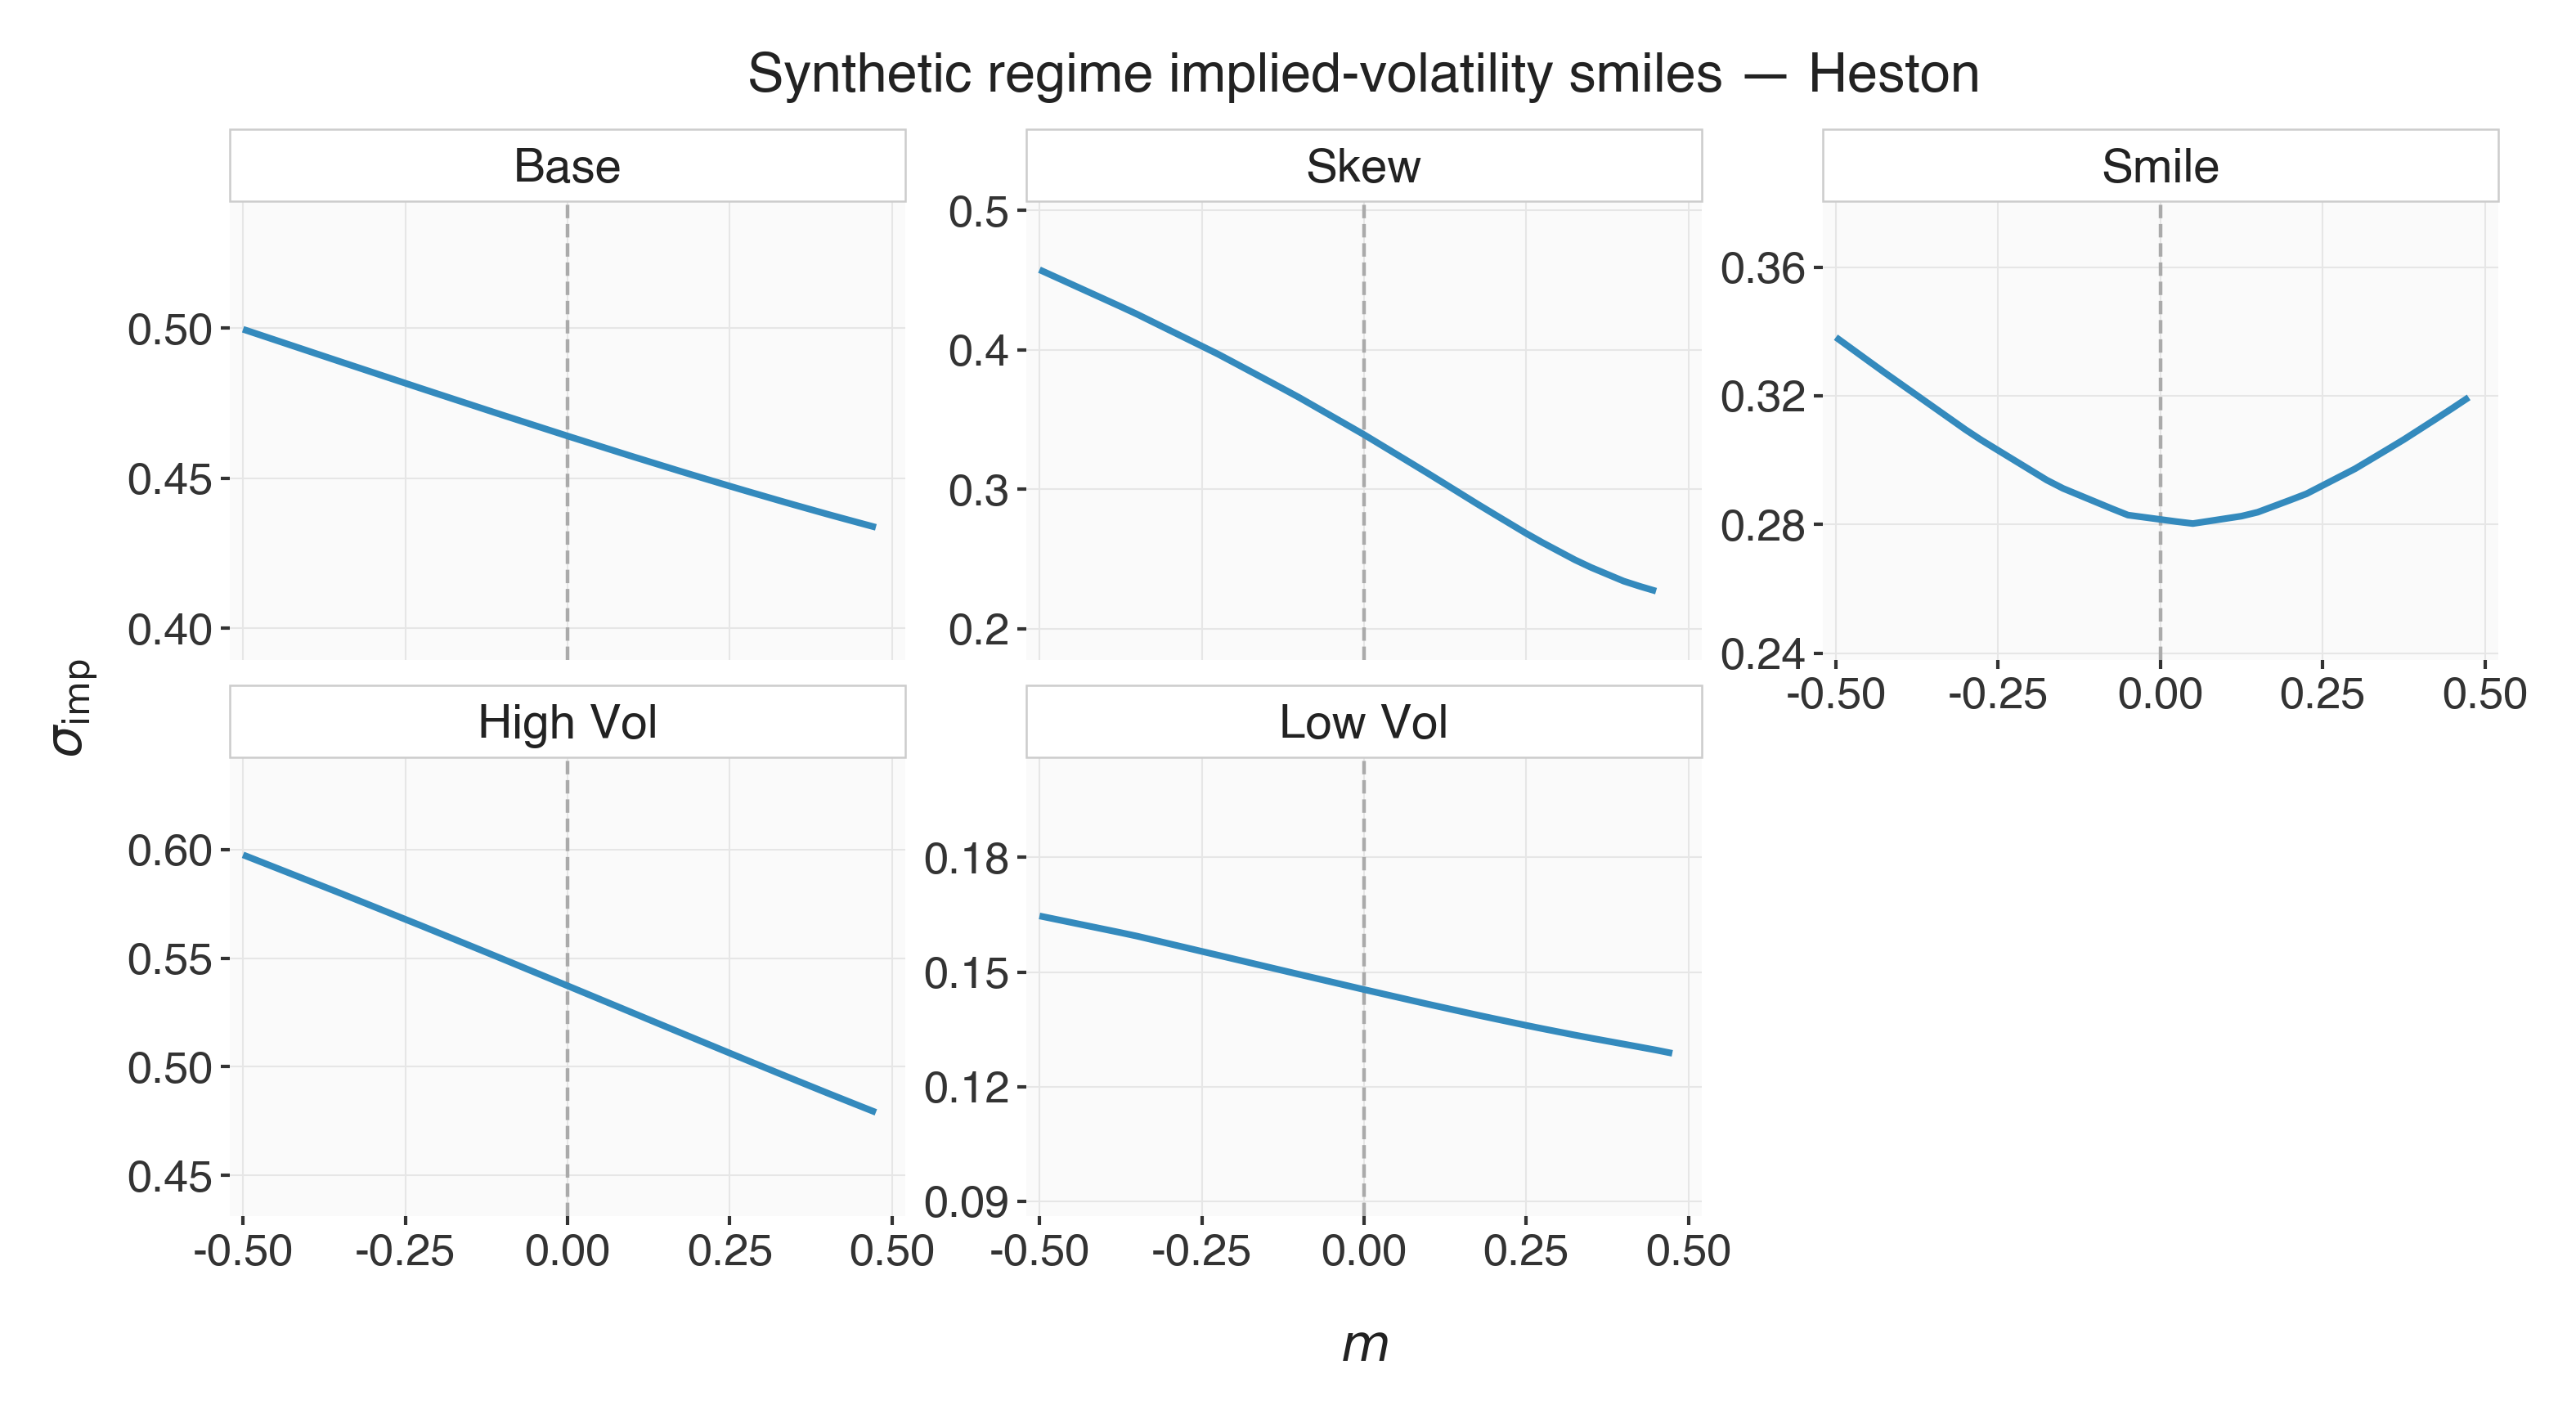

In [6]:
p_heston = plot_regime_smiles(
    heston_samples,
    tau_heston,
    model_name="Heston",
    save_stem="heston_regime_smiles",
)
p_heston


**Table — Heston parameters** (one draw per regime).

In [7]:
heston_params = pd.DataFrame(heston_param_rows).assign(
    regime=lambda d: d["regime"].map(_regime_label),
).set_index("regime").loc[REGIME_ORDER]
_style_param_table(heston_params.reset_index())


regime,v0,rho,sigma,theta,kappa,r
Base,0.198,-0.549,0.443,0.237,4.366,0.004
Skew,0.087,-0.825,0.834,0.174,3.179,0.007
Smile,0.086,-0.049,0.903,0.086,4.810,0.027
High Vol,0.446,-0.703,0.688,0.211,4.542,0.017
Low Vol,0.028,-0.569,0.073,0.017,4.794,0.048


## SABR — one sample per regime

In [8]:
SABR_REGIME_RANGES: dict[str, dict[str, list[float]]] = {
    "base": {"alpha": [0.05, 0.45], "rho": [-0.85, 0.85], "nu": [0.05, 0.90]},
    "skew": {"alpha": [0.10, 0.70], "rho": [-0.95, -0.55], "nu": [0.40, 0.95]},
    "smile": {"alpha": [0.20, 0.80], "rho": [-0.15, 0.15], "nu": [0.50, 1.10]},
    "high_vol": {"alpha": [0.70, 1.00], "rho": [-0.60, 0.10], "nu": [0.40, 1.10]},
    "low_vol": {"alpha": [0.03, 0.20], "rho": [-0.50, 0.10], "nu": [0.05, 0.40]},
}

sabr_base_cfg = merge_config_files(
    CFG_DIR / "sabr_iv_surface.yaml",
    CFG_DIR / "iv_surface_grid.yaml",
)

sabr_samples: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}
sabr_param_rows: list[dict[str, float | str]] = []
tau_sabr: np.ndarray | None = None

for regime, ranges in SABR_REGIME_RANGES.items():
    cfg = merge_config(
        sabr_base_cfg,
        {
            "sabr_ranges": ranges,
            "lhs": {
                "n_samples": 1,
                "n_batches": 1,
                "seed": REGIME_SEEDS[regime],
            },
        },
    )
    params, m_src, tau, iv = implied_vol_surfaces_sabr_lhs(cfg)
    m, iv_resampled = _resample_sample(m_src, tau, iv[0])
    sabr_samples[regime] = (params[0], m, iv_resampled)
    tau_sabr = UNIFIED_GRID.tau
    row = {"regime": regime}
    for i, name in enumerate(SABR_PARAM_ORDER):
        row[name] = float(params[0, i])
    sabr_param_rows.append(row)


**Table — SABR parameters** (one draw per regime; $\beta = 0.5$ fixed).

In [9]:
sabr_params = pd.DataFrame(sabr_param_rows).assign(
    regime=lambda d: d["regime"].map(_regime_label),
).set_index("regime").loc[REGIME_ORDER]
_style_param_table(sabr_params.reset_index())


regime,alpha,rho,nu
Base,0.339,0.001,0.158
Skew,0.181,-0.807,0.850
Smile,0.301,-0.049,1.042
High Vol,0.996,-0.403,0.787
Low Vol,0.124,-0.217,0.082


/Users/sbonelomdluli/Desktop/ivs-vit/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.
/Users/sbonelomdluli/Desktop/ivs-vit/.venv/lib/python3.12/site-packages/plotnine/geoms/geom_path.py:100: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


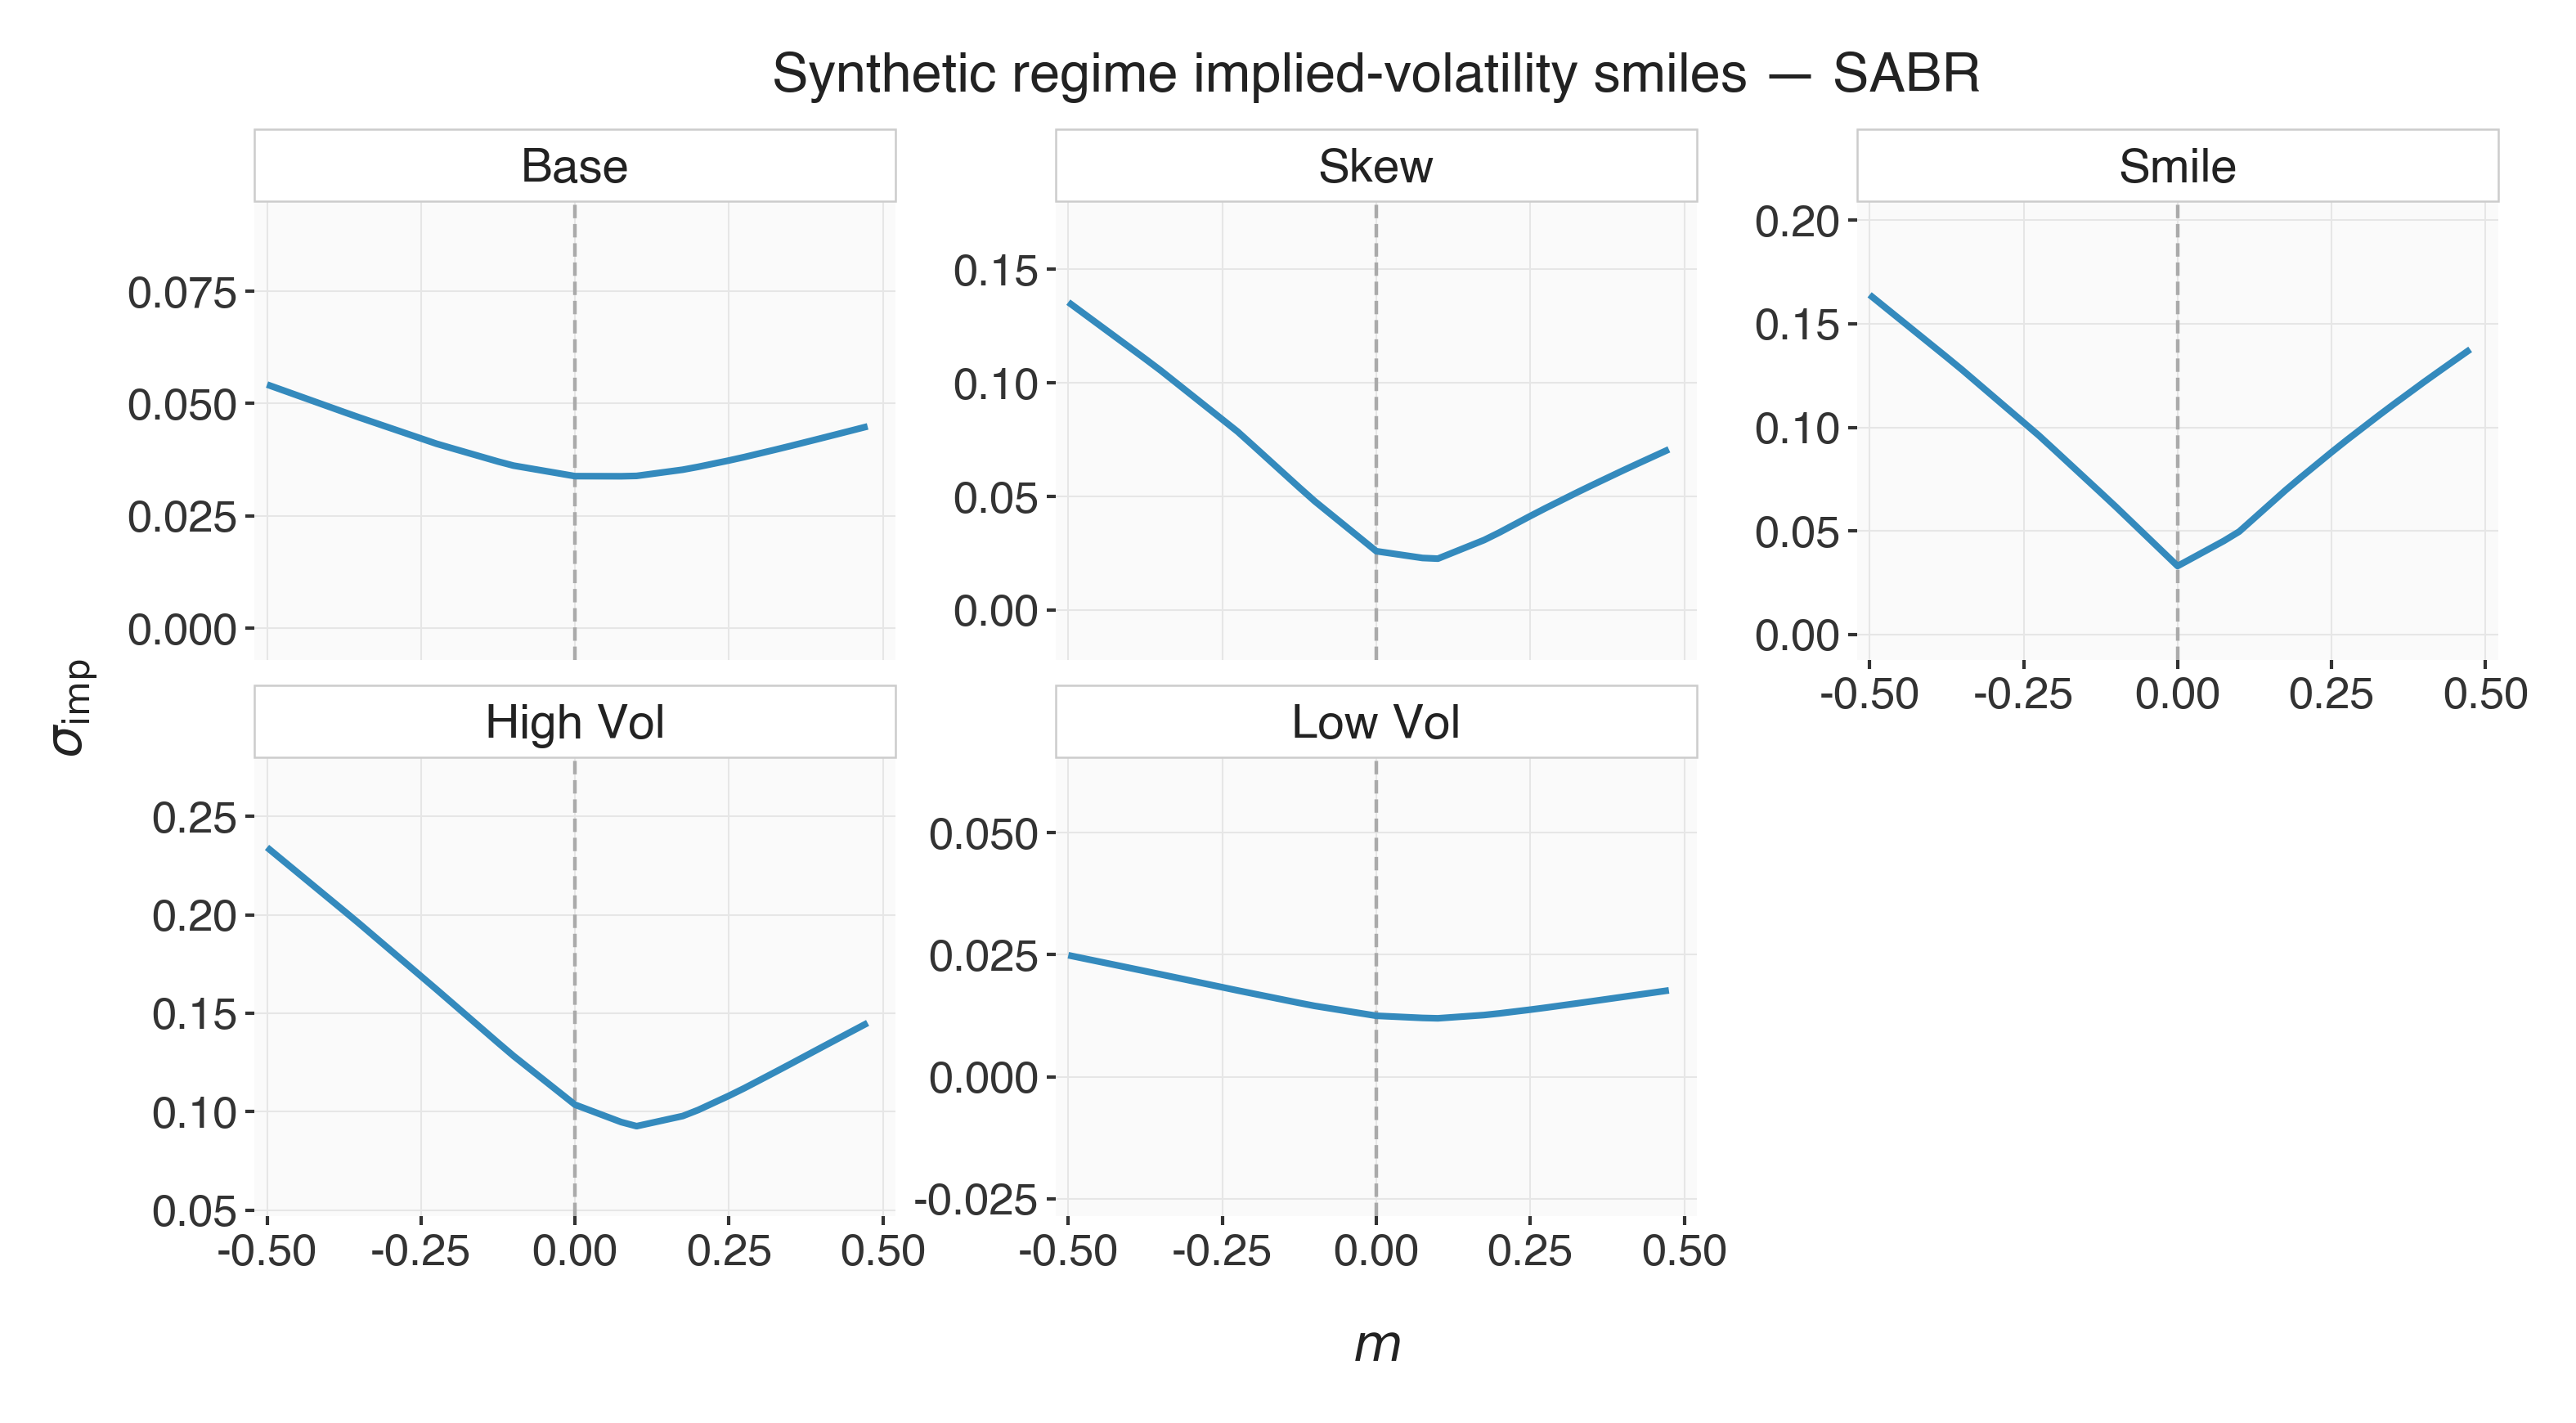

In [10]:
p_sabr = plot_regime_smiles(
    sabr_samples,
    tau_sabr,
    model_name="SABR",
    save_stem="sabr_regime_smiles",
)
p_sabr
